In [1]:
from cpymad.madx import Madx
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import hilbert

In [2]:
# initiate Mad-X
madx = Madx()


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Windows)     +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2025.01.10 18:55:20      +
  ++++++++++++++++++++++++++++++++++++++++++++



In [3]:
# parameters
u2MeV = 931.49410242 # [MeV]
circumference = 108.3160946 # [m], from esr.seq
n_turns = 1 # full turns of the ring
speed_light = 299792458 # [m/s]
elementary_charge = 1.602176634e-19 # [C]
u2kg = 1.66053906892e-27 #[kg/u]
me_kg = 9.1093837139e-31 # [kg]
me = 5.48579909441e-4 # [u]
MeV2u = 1.07354410083e-3 # [u/MeV]

In [4]:
Brho = 12.4
mass_p0, mass_p1 = 110.88049, 110.8784 # [u]
q_p0, q_p1 = 50, 49
gamma_beta_p0, gamma_beta_p1 = Brho/mass_p0 * q_p0 / speed_light / u2kg * elementary_charge, Brho/mass_p1 * q_p1 / speed_light / u2kg * elementary_charge
beta_p0, beta_p1 = gamma_beta_p0 / np.sqrt(1 + gamma_beta_p0**2), gamma_beta_p1 / np.sqrt(1 + gamma_beta_p1**2)
revtime_p0, revtime_p1 =  circumference/(speed_light*beta_p0)*1e9, circumference/(speed_light*beta_p1)*1e9

In [5]:
# input n_turns for .seq file
madx.input(f'n_turns = {n_turns};')
# call .seq
madx.call(file='ESRdoubleQuadError.seq')

In [6]:
# initiate beam with initial conditions
#beam_energy = 265.91305 # [MeV/u]
madx.command.beam(
    mass = mass_p0*u2MeV/1000, # input is GeV
    charge = q_p0,
    #energy = 110.88049*(u2MeV+beam_energy)/1000, # also GeV
    brho = Brho,
    sigt = 4.4616, # bunch length
    sige = 0.001, # rel energy spread
    kbunch = 18, # n bunches in machine
    radiate = True, # synchrotron radiation
    bunched = True,
)

# use the beam in the sequence and test twiss
madx.use(sequence = 'ESRring')
twiss = madx.twiss(deltap = '-0.005,0.0,0.005')

# tracking with ptc module

# invoke ptc tracking module
madx.command.ptc_create_universe()

# create layout
madx.command.ptc_create_layout(
    model = 2, # matrix-kick-matrix model
    method = 6, # integration order
    nst = 10, # No. of integration steps for each element
    offset_deltap = 0,
    exact = True, # flag to switch on exact hamiltonian
)
# addition options
madx.command.ptc_setswitch(
    fringe = True, # fringe file effects
    radiation = False, # synchrotron radiation
    time = True,
    totalpath = True,
    debuglevel = 2,
)

madx.command.ptc_align()
# initialise particle
madx.command.ptc_start(x= 0, px=0, y=0, py=0, pt=0.00)
#madx.command.ptc_start(x= 9e-3, px=0, y=9e-3, py=0)

madx.command.ptc_observe(place='E01DX4')
madx.command.ptc_observe(place='E02DX6')

madx.command.ptc_track(
        icase = 6, # Note that ICASE is internally set to 5/6 when attempting to set ICASE=6 with no cavity, and ICASE is internally set to 4 when attempting to set ICASE=6 with an RF cavity with zero voltage.
        #deltap = 0.02,
        closed_orbit = False, # co-ordinates specified with respect to actual closed orbit, not reference orbit (if True)
        dump = False,
        element_by_element = True,
        turns = 2000,
        maxaper = [0.24, 0.03, 0.05, 0.01, 1.0, 0.1], # maximum aperture
        file = 'data/00_ESR_track',
        extension = '.out',
)

# initiate Mad-X
madx = Madx()
# input n_turns for .seq file
madx.input(f'n_turns = {n_turns};')
# call .seq
madx.call(file='ESRdoubleQuadError.seq')

#beam_energy = 265.91313 # [MeV/u]
#madx.command.beam(
#    mass = 110.88049*u2MeV/1000, # input is GeV
#    charge = 50,
#    #energy = 110.88049*(u2MeV+beam_energy)/1000, # also GeV
#    brho = 2.4,
#    sigt = 4.4616, # bunch length
#    sige = 0.001, # rel energy spread
#    kbunch = 18, # n bunches in machine
#    radiate = True, # synchrotron radiation
#    bunched = True,
#)
madx.command.beam(
    mass = mass_p1*u2MeV/1000, # input is GeV
    charge = q_p1,
    #energy = 110.8784*(u2MeV+beam_energy)/1000, # also GeV
    brho = Brho,
    sigt = 4.4616, # bunch length
    sige = 0.001, # rel energy spread
    kbunch = 18, # n bunches in machine
    radiate = True, # synchrotron radiation
    bunched = True,
)

# use the beam in the sequence and test twiss
madx.use(sequence = 'ESRring')
twiss = madx.twiss(deltap = '-0.005,0.0,0.005')

# tracking with ptc module

# invoke ptc tracking module
madx.command.ptc_create_universe()

# create layout
madx.command.ptc_create_layout(
    model = 2, # matrix-kick-matrix model
    method = 6, # integration order
    nst = 10, # No. of integration steps for each element
    offset_deltap = 0,
    exact = True, # flag to switch on exact hamiltonian
)
# addition options
madx.command.ptc_setswitch(
    fringe = True, # fringe file effects
    radiation = False, # synchrotron radiation
    time = True,
    totalpath = True,
    debuglevel = 2,
)

madx.command.ptc_align()
# initialise particle
madx.command.ptc_start(x= 0, px=0, y=0, py=0, pt=0.)

madx.command.ptc_observe(place='E01DX4')
madx.command.ptc_observe(place='E02DX6')

madx.command.ptc_track(
        icase = 6, # Note that ICASE is internally set to 5/6 when attempting to set ICASE=6 with no cavity, and ICASE is internally set to 4 when attempting to set ICASE=6 with an RF cavity with zero voltage.
        #deltap = 0.02,
        closed_orbit = False, # co-ordinates specified with respect to actual closed orbit, not reference orbit (if True)
        dump = False,
        element_by_element = True,
        turns = 2000,
        maxaper = [0.24, 0.03, 0.05, 0.01, 1.0, 0.1], # maximum aperture
        file = 'data/01_ESR_track',
        extension = '.out',
)

enter Twiss module
  
iteration:   1 error:   7.449897E-03 deltap:  -5.000000E-03
orbit:  -5.907696E-03 -6.029613E-05  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00
  
iteration:   2 error:   2.797532E-05 deltap:  -5.000000E-03
orbit:  -5.923237E-03 -5.964027E-05  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00
  
iteration:   3 error:   1.740134E-10 deltap:  -5.000000E-03
orbit:  -5.923238E-03 -5.964027E-05  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00
++++++ warning: TWCPGO:  TWISS uses the RF system or synchrotron radiation only to find the closed orbit, for optical calculations it ignores both.

++++++ table: summ

            length             orbit5               alfa            gammatr 
       108.3160946                 -0       0.1629006543        2.477642178 

                q1                dq1            betxmax              dxmax 
       2.311467243       -4.756589696        35.64644459        6.522009762 

             dxrms             xcomax

True

In [7]:
obs001_00 = np.transpose(np.genfromtxt('./data/00_ESR_track.obs0002.p0001.out', skip_header=8))
obs002_00 = np.transpose(np.genfromtxt('./data/00_ESR_track.obs0003.p0001.out', skip_header=8))
obs001_01 = np.transpose(np.genfromtxt('./data/01_ESR_track.obs0002.p0001.out', skip_header=8))
obs002_01 = np.transpose(np.genfromtxt('./data/01_ESR_track.obs0003.p0001.out', skip_header=8))

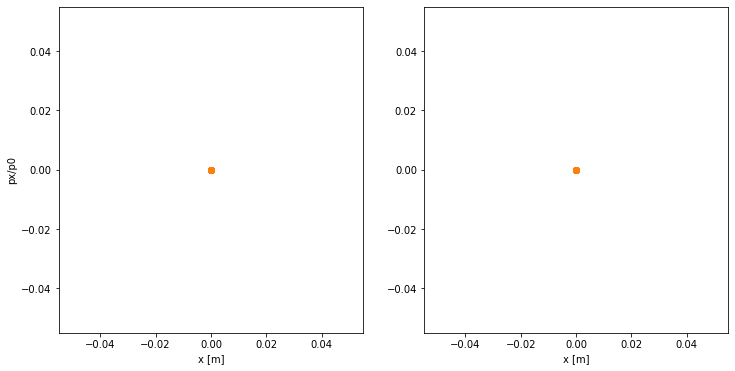

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].scatter(obs001_00[2], obs001_00[3], label='obs001', ls='-')
ax[0].scatter(obs002_00[2], obs002_00[3], label='obs002', ls='-')
ax[0].set_xlabel('x [m]')
ax[0].set_ylabel('px/p0')
ax[1].scatter(obs001_01[2], obs001_01[3], label='obs001', ls='-')
ax[1].scatter(obs002_01[2], obs002_01[3], label='obs002', ls='-')
ax[1].set_xlabel('x [m]')
plt.show()

In [9]:
time00 = obs001_00[6] - obs002_00[6]  
time01 = obs001_01[6] - obs002_01[6] 

print(np.average(time00)/revtime_p0)
print(np.average(time01)/revtime_p1)

-0.18686061958749248
-0.186860619566309


In [10]:
print(revtime_p0)

413.33787969712375


In [11]:
print(((np.average(time01)/revtime_p1)-(np.average(time00)/revtime_p0))/(np.average(time00)/revtime_p0))

-1.133650936738098e-10
